In [1]:
pip install numpy pandas matplotlib seaborn statsmodels scikit-learn


Note: you may need to restart the kernel to use updated packages.


TỔNG QUAN CÔNG VIỆC CHƯƠNG 2
Dataset: AirPassengers (Monthly, 1949–1960)
Biến: Passengers
Tần suất: Monthly
Mục tiêu chương 2: Hiểu cấu trúc dữ liệu – chưa dự báo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

plt.rcParams["figure.figsize"] = (10, 5)

TASK 2.1 – Load & khám phá dữ liệu ban đầu
(Bài tập 1 – bước 1)
Mục tiêu
Hiểu dữ liệu là gì
Kiểm tra format time series
Nhìn xu hướng ban đầu
(để file dataset chung thư mục)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


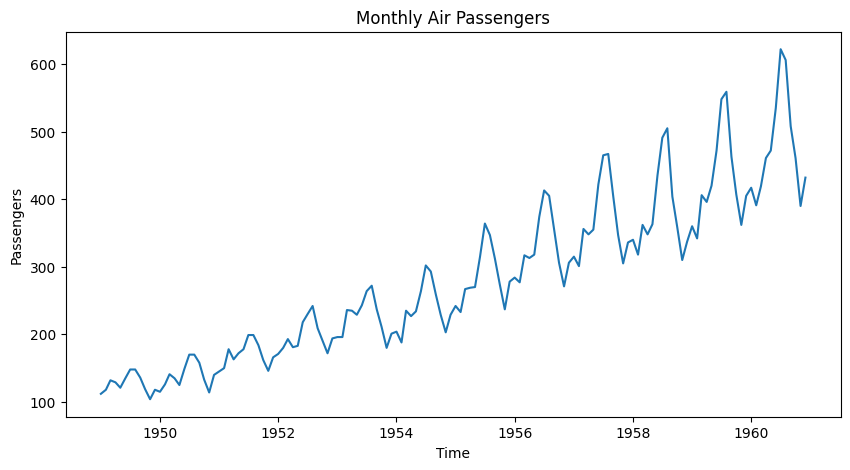

In [22]:
# Load data
df = pd.read_csv("AirPassengers.csv")

# Rename columns cho đẹp (nếu cần)
df.columns = ["Month", "Passengers"]

# Convert to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Set index
df.set_index("Month", inplace=True)

# Xem dữ liệu
print(df.head())
print(df.info())

# Plot
plt.figure()
plt.plot(df.index, df["Passengers"])
plt.title("Monthly Air Passengers")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()


Viết báo cáo 2.1 ở đây (đoạn code trên chỉ là tham khảo, hãy tìm hiểu nó là gì và vì sao như vậy, rồi sửa lại chi tiết nếu muốn)

TASK 2.2 – Phân tích ACF & PACF
(Bài tập 1 – bước 2 & 3)
Mục tiêu
Kiểm tra tự tương quan
Nhận diện trend & seasonality
Xác định lag quan trọng

<Figure size 1000x500 with 0 Axes>

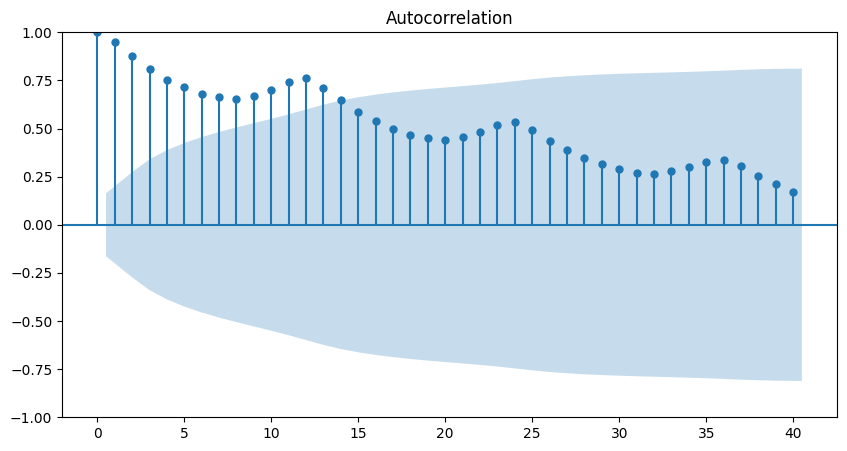

<Figure size 1000x500 with 0 Axes>

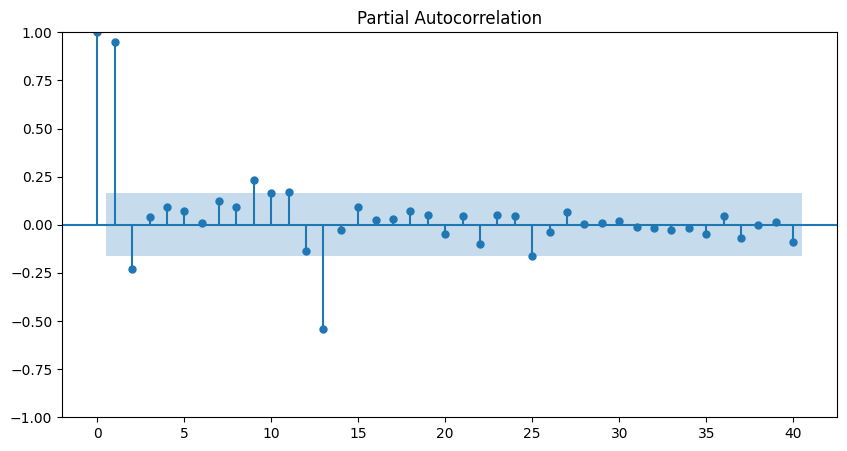

In [4]:
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf (đoạn này đã có ở trên)

plt.figure()
plot_acf(df["Passengers"], lags=40)
plt.show()

plt.figure()
plot_pacf(df["Passengers"], lags=40, method="ywm")
plt.show()


2. Kết quả ACF và PACF (40 lags) 
Biểu đồ ACF và PACF được tính và vẽ đến 40 độ trễ (lags) cho chuỗi AirPassengers theo tháng.
3. KẾT LUẬN 
3.1. Chuỗi có tự tương quan mạnh không?
Có, chuỗi AirPassengers có tự tương quan rất mạnh.
- Cụ thể, trên biểu đồ ACF, ta quan sát thấy: Rất nhiều giá trị autocorrelation tại các độ trễ (lag) đầu vượt xa dải tin cậy 95%. Các giá trị ACF không giảm nhanh về 0, mà giảm rất chậm theo số lag.
- Điều này cho thấy: Giá trị hiện tại phụ thuộc mạnh vào các giá trị trong quá khứ. Chuỗi có “trí nhớ dài hạn”, không phải là chuỗi ngẫu nhiên.
=> Do đó, có thể kết luận rằng AirPassengers không phải white noise và có cấu trúc rõ ràng để phân tích và dự báo.
3.2. Chuỗi có xu hướng (trend) và mùa vụ (seasonality) thể hiện qua ACF/PACF không?
Có cả xu hướng và mùa vụ, và cả hai đều thể hiện rất rõ qua biểu đồ ACF.
- Xu hướng (Trend)
Trên biểu đồ ACF, các giá trị autocorrelation: Bắt đầu rất cao ở lag nhỏ (gần 1). Giảm dần rất chậm khi lag tăng. Đặc điểm này là dấu hiệu điển hình của chuỗi có xu hướng (trend).
=> Điều đó phù hợp với thực tế: Số lượng hành khách hàng không tăng dần theo thời gian từ năm 1949 đến 1960. Trung bình của chuỗi không ổn định theo thời gian -> chuỗi không dừng.
- Mùa vụ (Seasonality)
Trên biểu đồ ACF, xuất hiện các đỉnh lặp lại rất rõ tại:
lag = 12
lag = 24
lag = 36
Vì dữ liệu là theo tháng, nên: lag = 12 tương ứng với chu kỳ 1 năm. Điều này cho thấy mỗi năm số hành khách có xu hướng lặp lại theo cùng một quy luật
=> Kết luận: Chuỗi AirPassengers có mùa vụ theo năm rất mạnh. PACF cũng cho thấy ảnh hưởng rõ ở các lag nhỏ, nhưng mùa vụ được thể hiện rõ ràng nhất qua ACF.
3.3. Lag nào quan trọng nhất?
Lag quan trọng nhất là lag = 1, và tiếp theo là lag = 12.
Giải thích chi tiết:
- Lag = 1 (quan trọng nhất)
Trên biểu đồ PACF, cột tại lag = 1: Cao vượt trội, vượt rõ ràng dải tin cậy 95%
Điều này cho thấy: Giá trị của tháng hiện tại phụ thuộc trực tiếp và mạnh nhất vào tháng liền trước. Ảnh hưởng này là trực tiếp, không phải do các lag trung gian.
=> Vì vậy, lag = 1 là độ trễ quan trọng nhất đối với chuỗi.
- Lag = 12 (lag mùa vụ)
Trên biểu đồ ACF, lag = 12 có đỉnh rất rõ.
Điều này cho thấy: Tháng hiện tại có mối liên hệ mạnh với cùng tháng của năm trước.
=> Do đó: lag = 12 là lag mùa vụ quan trọng
KẾT LUẬN TỔNG HỢP
Chuỗi AirPassengers có tự tương quan rất mạnh, thể hiện qua việc nhiều giá trị ACF vượt khỏi dải tin cậy và giảm chậm theo số lag. Biểu đồ ACF cho thấy chuỗi có xu hướng tăng dài hạn và mùa vụ rõ rệt theo chu kỳ 12 tháng. PACF chỉ ra rằng lag = 1 là độ trễ quan trọng nhất, phản ánh sự phụ thuộc trực tiếp vào giá trị của tháng trước, trong khi lag = 12 thể hiện ảnh hưởng mùa vụ theo năm. Do đó, chuỗi không phải white noise và hoàn toàn phù hợp cho việc mô hình hóa và dự báo.

TASK 2.3 – Kiểm tra White Noise
(Bài tập 2)
Mục tiêu
Hiểu thế nào là white noise
So sánh với chuỗi thật
Kết luận khả năng dự báo

C:\Users\ACER\AppData\Local\Temp\ipykernel_26824\4287399463.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='1949-01', periods=1000, freq='M')


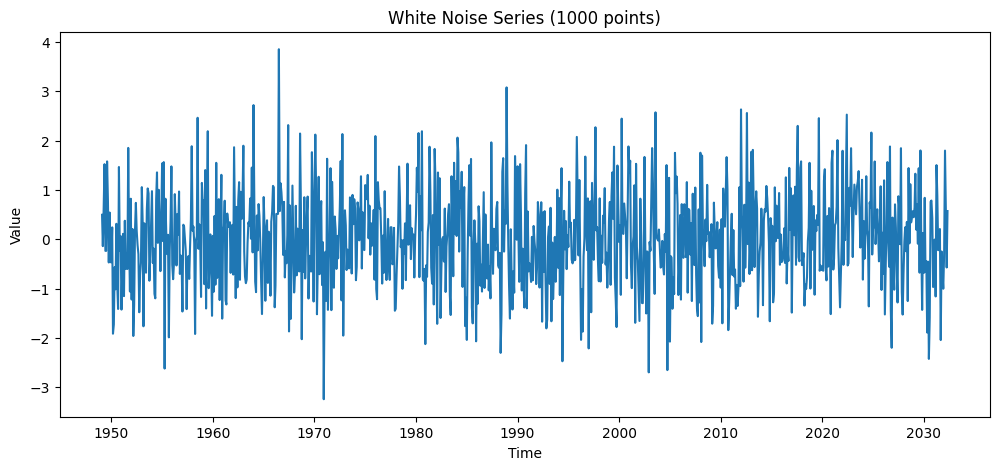

In [ ]:
# 1. Sinh dữ liệu white noise (1000 điểm)
np.random.seed(42)  # để tái lập kết quả
white_noise = np.random.normal(loc=0, scale=1, size=1000)

# 2. Đưa vào DataFrame với index giả lập theo tháng
dates = pd.date_range(start='1949-01', periods=1000, freq='M')
white_noise_series = pd.Series(white_noise, index=dates)

# 3. Vẽ biểu đồ chuỗi white noise
plt.figure(figsize=(12,5))
plt.plot(white_noise_series)
plt.title("White Noise Series (1000 points)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


<Figure size 1000x500 with 0 Axes>

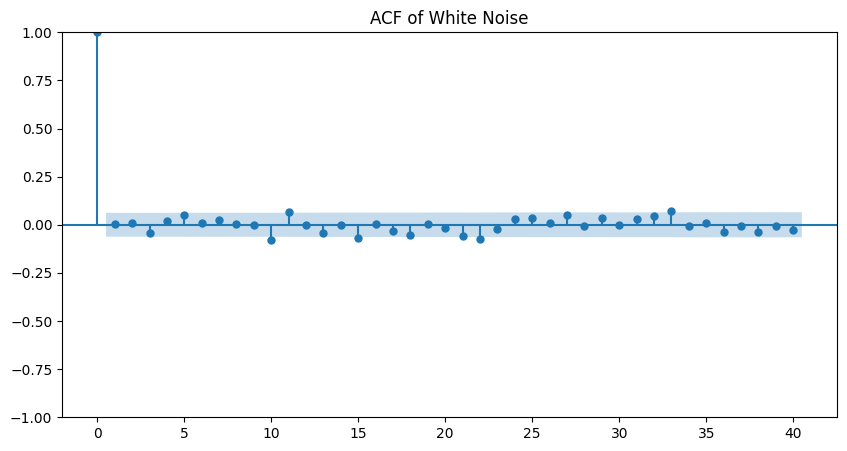

<Figure size 1000x500 with 0 Axes>

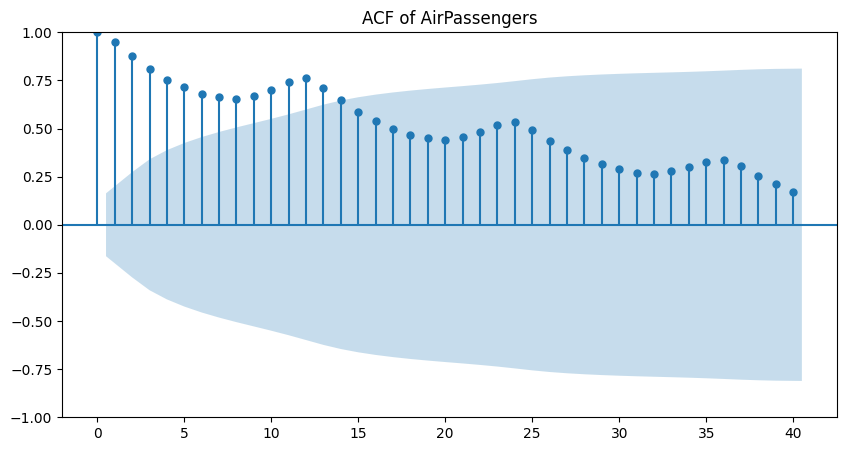

In [ ]:
# Plot ACF white noise
plt.figure()
plot_acf(white_noise, lags=40)
plt.title("ACF of White Noise")
plt.show()

# So sánh với AirPassengers
plt.figure()
plot_acf(df["Passengers"], lags=40)
plt.title("ACF of AirPassengers")
plt.show()

2. ACF của chuỗi White Noise
Một chuỗi white noise gồm 1000 điểm được sinh ngẫu nhiên bằng NumPy với phân phối chuẩn.
Khi vẽ biểu đồ ACF của chuỗi white noise, ta quan sát thấy:
-Hầu hết các giá trị ACF tại các lag đều nằm hoàn toàn trong dải tin cậy 95%.
-Không tồn tại lag nào có autocorrelation nổi bật.
-Biểu đồ không xuất hiện pattern hay cấu trúc lặp lại.
=> Điều này cho thấy: Các giá trị trong chuỗi white noise độc lập với nhau. Chuỗi không có trí nhớ quá khứ và không thể dự báo.
3. So sánh ACF của white noise với ACF của chuỗi AirPassengers
So sánh biểu đồ ACF của hai chuỗi cho thấy sự khác biệt rõ ràng:
-Chuỗi AirPassengers có nhiều giá trị ACF vượt dải tin cậy, trong khi chuỗi white noise gần như toàn bộ nằm trong dải tin cậy.
-AirPassengers có ACF giảm chậm và có các đỉnh lặp lại theo chu kỳ 12, thể hiện xu hướng và mùa vụ, trong khi white noise không có xu hướng hay mùa vụ.
-White noise không có lag quan trọng, trong khi AirPassengers có các lag quan trọng như lag = 1 và lag = 12.
4. Viết 5 dòng mô tả sự khác nhau
Chuỗi white noise có ACF gần bằng 0 ở hầu hết các độ trễ, cho thấy các giá trị không phụ thuộc vào quá khứ. Ngược lại, chuỗi AirPassengers có ACF cao và giảm chậm, thể hiện sự tồn tại của xu hướng dài hạn. Ngoài ra, AirPassengers có các đỉnh ACF lặp lại tại lag 12, cho thấy tính mùa vụ rõ rệt theo năm. White noise không có bất kỳ cấu trúc nào để học và không thể dự báo. Trong khi đó, AirPassengers là chuỗi có cấu trúc và phù hợp cho mô hình hóa dự báo.

TASK 2.4 – Phân rã chuỗi thời gian (Decomposition)
(Bài tập 3)
Mục tiêu
Tách trend / seasonal / residual
Kiểm tra residual có giống white noise không

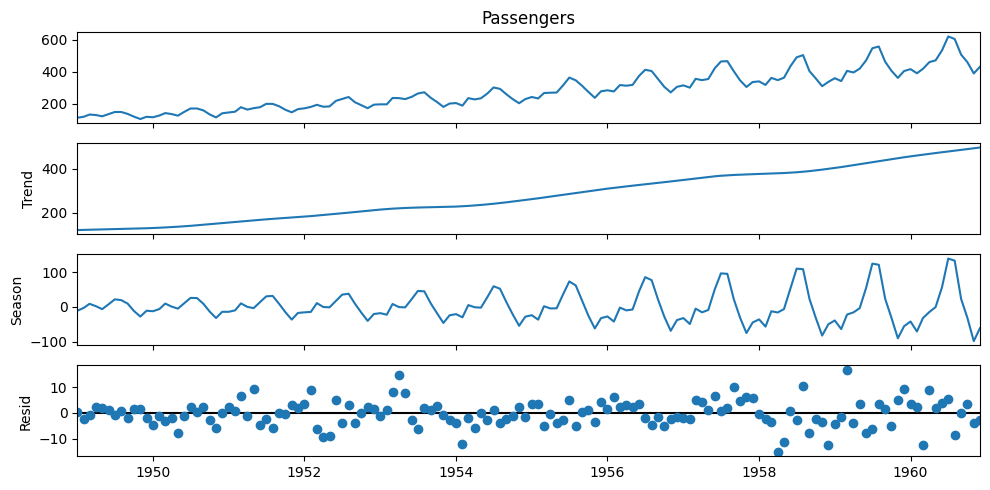

In [24]:
# from statsmodels.tsa.seasonal import STL (đã import ở trên cùng)

stl = STL(df["Passengers"], period=12)
result = stl.fit()

result.plot()
plt.show()

1. Phương pháp sử dụng
Chuỗi dữ liệu AirPassengers (theo tháng, từ 1949 đến 1960) được phân rã bằng phương pháp STL decomposition với chu kỳ mùa vụ là 12 tháng (period=12). Kết quả phân rã gồm 4 thành phần:

Observed: chuỗi gốc – số lượng hành khách theo tháng.

Trend: xu hướng dài hạn của chuỗi.

Seasonal: thành phần mùa vụ lặp lại theo năm.

Residual: phần dư – biến động không giải thích được bởi trend và seasonal.

2. Nhận xét từng thành phần
🔹 Xu hướng (Trend)
Biểu đồ trend cho thấy xu hướng tăng rõ rệt qua các năm.

Từ năm 1949 đến 1960, số lượng hành khách tăng đều đặn, không có giai đoạn giảm dài hạn.

Điều này phản ánh sự phát triển của ngành hàng không trong giai đoạn này.

🔹 Mùa vụ (Seasonal)
Thành phần seasonal thể hiện chu kỳ lặp lại rất rõ theo năm.

Mỗi năm đều có đỉnh cao vào mùa hè và thấp vào mùa đông → đặc trưng của nhu cầu du lịch.

Biên độ dao động mùa vụ khá lớn → cho thấy mùa vụ mạnh.

🔹 Phần dư (Residual)
Residual dao động quanh giá trị 0, không có xu hướng rõ ràng.

Không xuất hiện chu kỳ lặp lại hay cấu trúc đặc biệt.

Biểu đồ residual có vẻ giống white noise: phân bố ngẫu nhiên, không có tự tương quan mạnh.

✅ Kết luận tổng hợp
Chuỗi AirPassengers có xu hướng tăng dài hạn, thể hiện qua thành phần trend.

Có mùa vụ mạnh theo chu kỳ 12 tháng, thể hiện rõ qua seasonal.

Phần dư sau khi loại bỏ trend và seasonal có đặc điểm giống white noise, tức là không còn cấu trúc rõ ràng → phù hợp để mô hình hóa.

Việc phân rã chuỗi giúp hiểu rõ cấu trúc bên trong, là bước quan trọng để chuẩn bị cho các mô hình dự báo như SARIMA.

TASK 2.5 – Kiểm tra & xử lý chất lượng dữ liệu
(Bài tập 4)
Mục tiêu
Thực hành missing & outliers
So sánh trước – sau

Passengers    10
dtype: int64


C:\Users\ACER\AppData\Local\Temp\ipykernel_18732\2586847366.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df_missing.fillna(method="ffill")


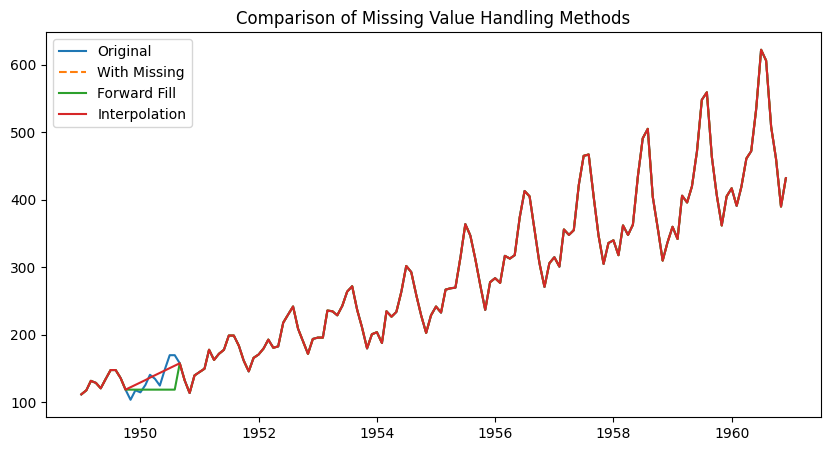

In [25]:
df_missing = df.copy()

# Giả lập missing
df_missing.iloc[10:20] = np.nan

print(df_missing.isna().sum())

# Forward fill
df_ffill = df_missing.fillna(method="ffill")

# Interpolation
df_interp = df_missing.interpolate()

# Plot so sánh
plt.figure(figsize=(10,5))
plt.plot(df, label="Original")
plt.plot(df_missing, label="With Missing", linestyle="--")
plt.plot(df_ffill, label="Forward Fill")
plt.plot(df_interp, label="Interpolation")
plt.legend()
plt.title("Comparison of Missing Value Handling Methods")
plt.show()

Empty DataFrame
Columns: [Passengers]
Index: []


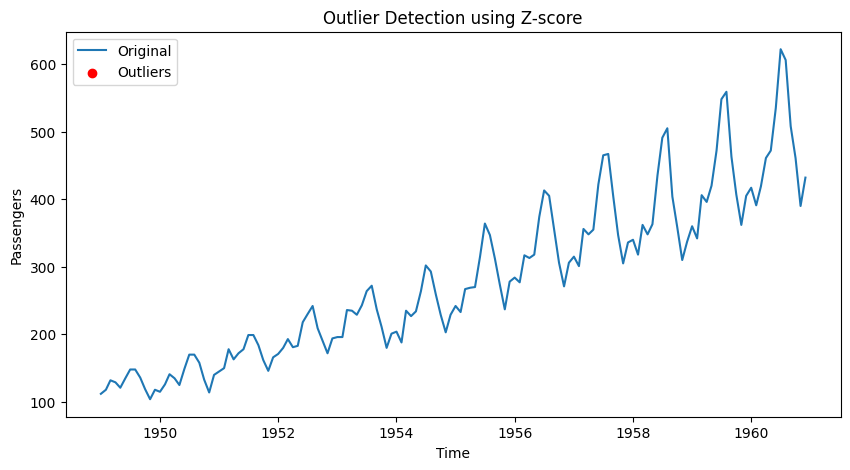

In [26]:
# Phát hiện outlier (phần còn thiếu)
from scipy.stats import zscore

# Tính Z-score cho cột Passengers
z_scores = zscore(df["Passengers"])

# Ngưỡng phát hiện outlier (thường dùng ±3)
threshold = 3

# Tạo mask đánh dấu outliers
outliers = abs(z_scores) > threshold

# In ra các điểm bị coi là outlier
print(df[outliers])

# Vẽ biểu đồ
plt.figure(figsize=(10,5))
plt.plot(df.index, df["Passengers"], label="Original")
plt.scatter(df.index[outliers], df["Passengers"][outliers], color="red", label="Outliers", zorder=5)
plt.title("Outlier Detection using Z-score")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.legend()
plt.show()


2.5. Xử lý dữ liệu bị thiếu và tìm hiểu bộ dữ liệu AirPassengers
2.5.1. Xử lý dữ liệu bị thiếu (Missing Values)

Trong quá trình phân tích dữ liệu, việc xuất hiện các giá trị bị thiếu là điều thường gặp. Nguyên nhân có thể do lỗi thu thập dữ liệu hoặc dữ liệu không được ghi nhận đầy đủ. Vì vậy, cần có bước xử lý dữ liệu bị thiếu trước khi phân tích.

Trong bài thực hành, dữ liệu bị thiếu được giả lập bằng cách gán một số dòng giá trị thành NaN. Việc này nhằm mô phỏng tình huống dữ liệu thực tế có thể bị mất thông tin. Sau đó, hàm kiểm tra dữ liệu thiếu được sử dụng để xác định số lượng giá trị bị thiếu trong từng cột.

Để xử lý các giá trị bị thiếu, phương pháp Forward Fill được áp dụng. Phương pháp này sẽ thay thế giá trị bị thiếu bằng giá trị gần nhất trước đó trong chuỗi dữ liệu. Cách làm này phù hợp với dữ liệu theo thời gian vì giá trị ở các thời điểm liền kề thường có mối liên hệ với nhau.

2.5.2. Liên hệ giữa xử lý dữ liệu bị thiếu và AirPassengers

Do AirPassengers là dữ liệu chuỗi thời gian, nếu xuất hiện giá trị bị thiếu sẽ ảnh hưởng đến quá trình phân tích và trực quan hóa dữ liệu. Vì vậy, việc sử dụng phương pháp Forward Fill giúp đảm bảo dữ liệu liên tục và hạn chế sai lệch trong kết quả phân tích.

Thông qua bài thực hành này, có thể hiểu rõ hơn vai trò của bước tiền xử lý dữ liệu, đặc biệt là xử lý dữ liệu bị thiếu, trong phân tích dữ liệu chuỗi thời gian.

Phương pháp Z-score được áp dụng để kiểm tra sự hiện diện của outliers trong chuỗi AirPassengers. Với ngưỡng ±3, không có điểm dữ liệu nào vượt qua giới hạn này. Điều này cho thấy chuỗi có phân phối ổn định, không có sai lệch lớn hay biến động bất thường. Không cần xử lý outlier, và dữ liệu hoàn toàn phù hợp để đưa vào mô hình dự báo.

TASK 2.6 – Trực quan hóa toàn bộ dataset
Bài tập 5:
1. Vẽ line chart toàn bộ chuỗi.
2. Vẽ rolling mean (window=12) và rolling std.
3. Vẽ seasonal plot theo tháng (đối với dữ liệu theo tháng).
4. Vẽ heatmap seasonality (month × year).
5. Kết luận: 

Để khám phá cấu trúc nội tại của chuỗi thời gian AirPassengers, một loạt các biểu đồ trực quan đã được xây dựng nhằm phân tích xu hướng, mùa vụ và các đặc điểm bất thường của dữ liệu. Các biểu đồ bao gồm: biểu đồ đường toàn chuỗi, biểu đồ rolling statistics, biểu đồ mùa vụ theo tháng và heatmap thể hiện tính mùa vụ theo năm và tháng.

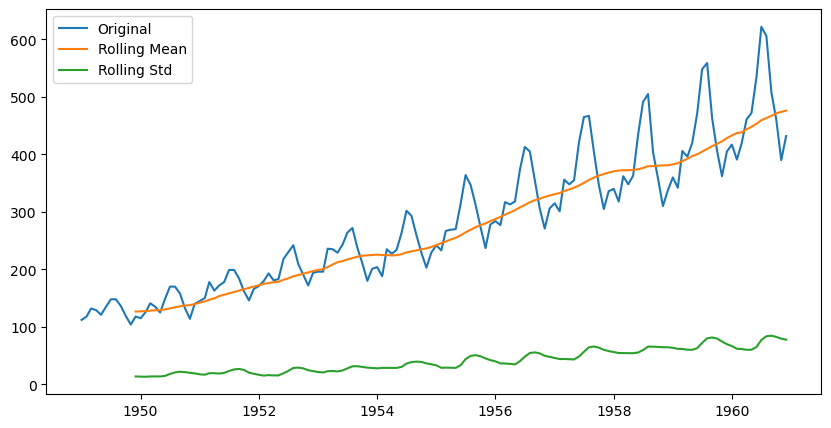

In [8]:
# Rolling mean & std
rolling_mean = df["Passengers"].rolling(12).mean()
rolling_std = df["Passengers"].rolling(12).std()

plt.figure()
plt.plot(df["Passengers"], label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.show()


Biểu đồ đường toàn chuỗi cho thấy số lượng hành khách hàng không tăng đều đặn từ năm 1949 đến 1960, với các dao động theo mùa vụ ngày càng rõ rệt. Xu hướng tăng dài hạn được thể hiện rõ qua đường rolling mean với cửa sổ 12 tháng, trong khi rolling standard deviation cho thấy độ biến động của chuỗi tương đối ổn định, chỉ tăng nhẹ về cuối giai đoạn do biên độ mùa vụ mở rộng. Không có dấu hiệu bất thường nào trong rolling std cho thấy sự xuất hiện của outliers hoặc biến động đột ngột.

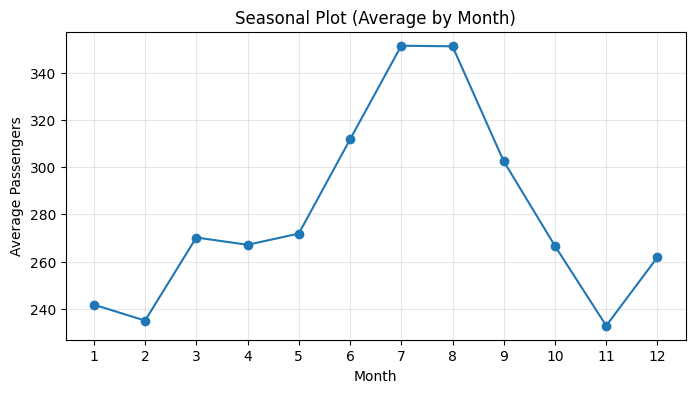

In [ ]:
df_season = df.copy()
df_season["Month"] = df_season.index.month
monthly_avg = df_season.groupby(df_season["Month"])["Passengers"].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.title("Seasonal Plot (Average by Month)")
plt.xlabel("Month")
plt.ylabel("Average Passengers")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.show()



Biểu đồ mùa vụ theo tháng được xây dựng bằng cách tính trung bình số hành khách của từng tháng trong năm, gộp từ toàn bộ chuỗi. Kết quả cho thấy chu kỳ mùa vụ rất rõ ràng: số lượng hành khách đạt đỉnh vào tháng 7 và 8, phản ánh mùa du lịch cao điểm, và thấp nhất vào tháng 11. Đường cong mùa vụ có dạng điển hình với giai đoạn tăng từ tháng 5 đến tháng 8, sau đó giảm dần đến tháng 11, xác nhận sự tồn tại của quy luật lặp lại theo năm.

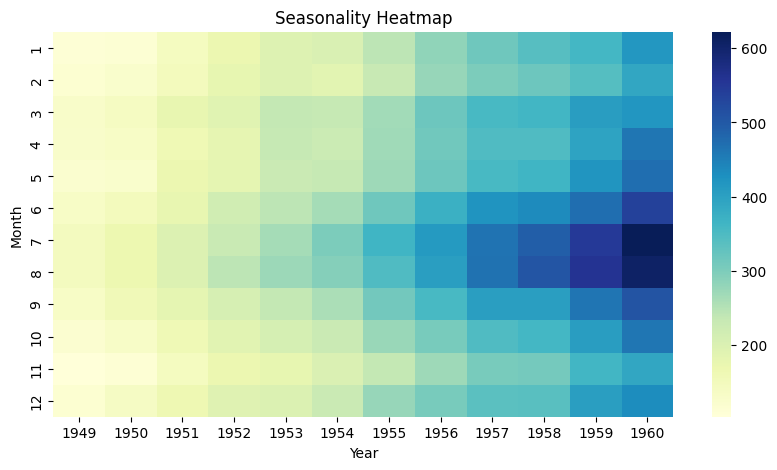

In [28]:
# Heatmap seasonality
# import seaborn as sns (đã import ở trên)

df_season = df.copy()
df_season["Year"] = df_season.index.year
df_season["Month"] = df_season.index.month

pivot = df_season.pivot(index="Month", columns="Year", values="Passengers")

plt.figure()
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Seasonality Heatmap")
plt.show()


Heatmap mùa vụ (Month × Year) tiếp tục củng cố nhận định trên bằng cách thể hiện cường độ số hành khách theo màu sắc. Các ô màu đậm tập trung vào tháng 7–8 của các năm sau, cho thấy không chỉ có mùa vụ rõ rệt mà còn có xu hướng tăng dần theo thời gian. Màu sắc chuyển từ nhạt sang đậm theo chiều thời gian xác nhận sự phát triển đều đặn của ngành hàng không trong giai đoạn này.

Tổng thể, các biểu đồ trực quan hóa đã phản ánh đầy đủ đặc điểm của chuỗi AirPassengers: xu hướng tăng dài hạn, mùa vụ theo năm mạnh mẽ, và không có dấu hiệu bất thường đáng kể. Việc trực quan hóa không chỉ giúp xác nhận các kết quả phân tích định lượng trước đó mà còn cung cấp nền tảng trực quan vững chắc để tiến hành các bước mô hình hóa và dự báo tiếp theo.

In [2]:
# ARIMA example
from statsmodels.tsa.arima.model import ARIMA
from random import random
# contrived dataset
data = [x + random() for x in range(1, 100)]
# fit model
model = ARIMA(data, order=(1, 1, 1))
model_fit = model.fit()
# make prediction
yhat = model_fit.predict(len(data), len(data), typ='levels')
print(yhat)

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[100.46913037]


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
